In [8]:
import piplite
await piplite.install(['nbformat', 'seaborn', 'plotly'])

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Dataset load
df = pd.read_csv('yeild_data.csv')

# Clean state/crop names (capitalize for clean presentation)
df['State_Name'] = df['State_Name'].str.title()
df['Crop'] = df['Crop'].str.title()
df['Season'] = df['Season'].str.strip().str.title()

print("Data Loaded Successfully!")
print("Dataset Shape:", df.shape)
df.head()

Data Loaded Successfully!
Dataset Shape: (231609, 8)


,State_Name,Crop_Year,Season,Crop,Area,Production,Yeild,Rainfall
0,Andaman And Nicobar Islands,2000,Kharif,Arecanut,1254.0,2000.0,1.594896,1244.2
1,Andaman And Nicobar Islands,2000,Kharif,Rice,102.0,321.0,3.147059,1244.2
2,Andaman And Nicobar Islands,2000,Whole Year,Banana,176.0,641.0,3.642045,2763.2
3,Andaman And Nicobar Islands,2000,Whole Year,Cashewnut,720.0,165.0,0.229167,2763.2
4,Andaman And Nicobar Islands,2000,Whole Year,Coconut,18168.0,65100000.0,3583.223250,2763.2


In [6]:
#*************SUMMARY STATISTICS AND DATA CLEANING****************
# Check for missing values in the dataset
print("Missing Values Count:")
print(df.isnull().sum())

# Display basic summary statistics of numerical columns
print("\nDataset Summary Statistics:")
display(df.describe())

Missing Values Count:
State_Name    0
Crop_Year     0
Season        0
Crop          0
Area          0
Production    0
Yeild         0
Rainfall      0
dtype: int64

Dataset Summary Statistics:


,Crop_Year,Area,Production,Yeild,Rainfall
count,231609.000000,2.316090e+05,2.316090e+05,231609.000000,231609.000000
mean,2005.660402,1.217855e+04,6.073611e+05,40.668370,719.952237
std,4.962559,3.856970e+04,1.745646e+07,814.676381,688.613306
min,1997.000000,1.000000e-01,0.000000e+00,0.000000,0.000000
25%,2002.000000,8.800000e+01,9.400000e+01,0.531915,102.100000
50%,2006.000000,6.200000e+02,7.960000e+02,1.000000,537.150000
75%,2010.000000,4.757810e+03,7.632000e+03,2.467294,1148.300000
max,2015.000000,1.020181e+06,1.250800e+09,88000.000000,3825.200000


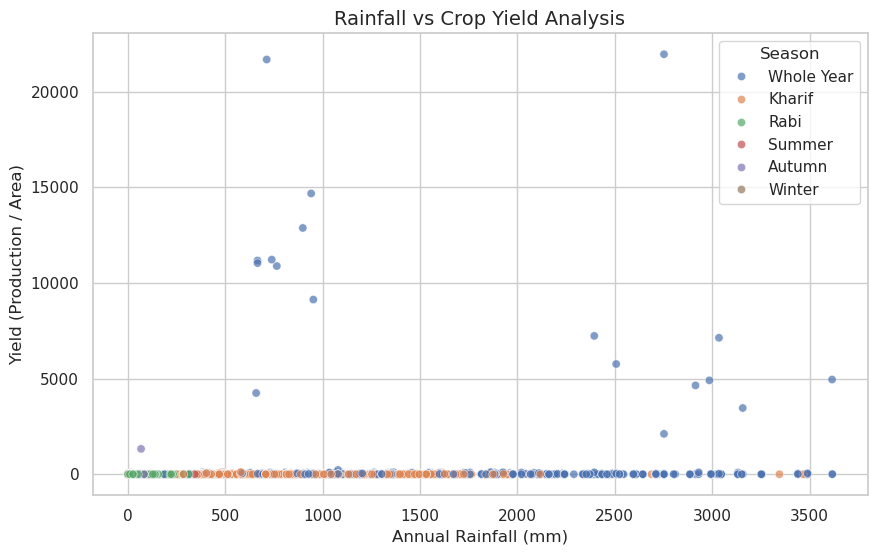

In [11]:
#***************CROP YIELD VS RAINFALL ANALYSIS(SCATTER PLOT)************************
# Import required visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Sample 5,000 rows for smooth visualization in JupyterLite
sampled_df = df.sample(n=5000, random_state=42)

# Set figure size and grid style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create scatter plot using Seaborn
sns.scatterplot(
    data=sampled_df,
    x='Rainfall',
    y='Yeild',
    hue='Season',
    alpha=0.7
)

# Add titles and axis labels
plt.title("Rainfall vs Crop Yield Analysis", fontsize=14)
plt.xlabel("Annual Rainfall (mm)", fontsize=12)
plt.ylabel("Yield (Production / Area)", fontsize=12)

# Display plot directly
plt.show()

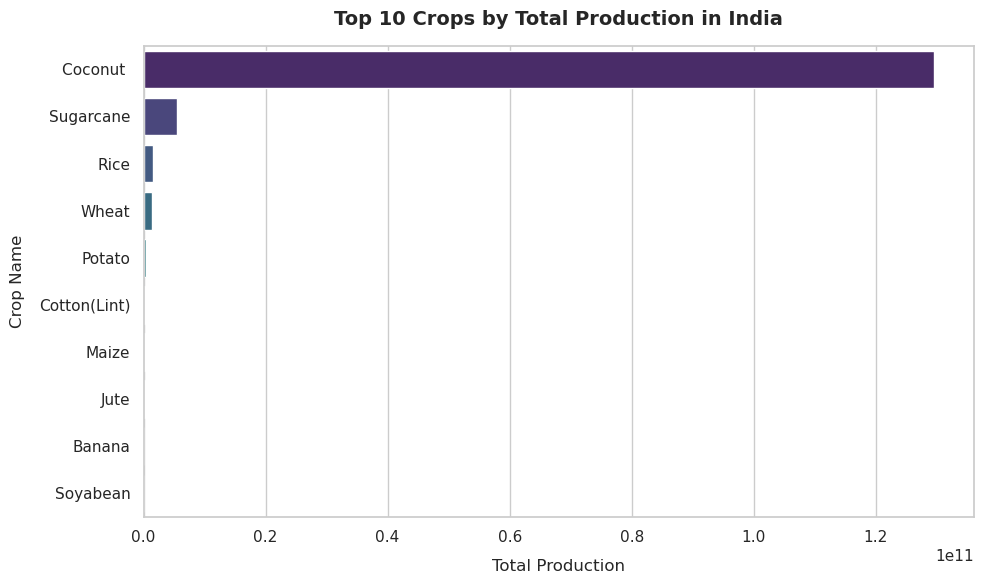

In [12]:
#************TOP 10 CROPS BY TOTAL PRODUCTION(BAR CHART)****************
# Aggregate total production by crop name and select top 10 crops
top_crops = df.groupby('Crop')['Production'].sum().nlargest(10).reset_index()

# Set plot style and figure size
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create horizontal bar plot with vibrant palette
ax = sns.barplot(
    data=top_crops,
    x='Production',
    y='Crop',
    palette="viridis",
    hue='Crop',
    legend=False
)

# Add title and labels
plt.title("Top 10 Crops by Total Production in India", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Total Production", fontsize=12, labelpad=10)
plt.ylabel("Crop Name", fontsize=12, labelpad=10)

# Render plot inline
plt.tight_layout()
plt.show()

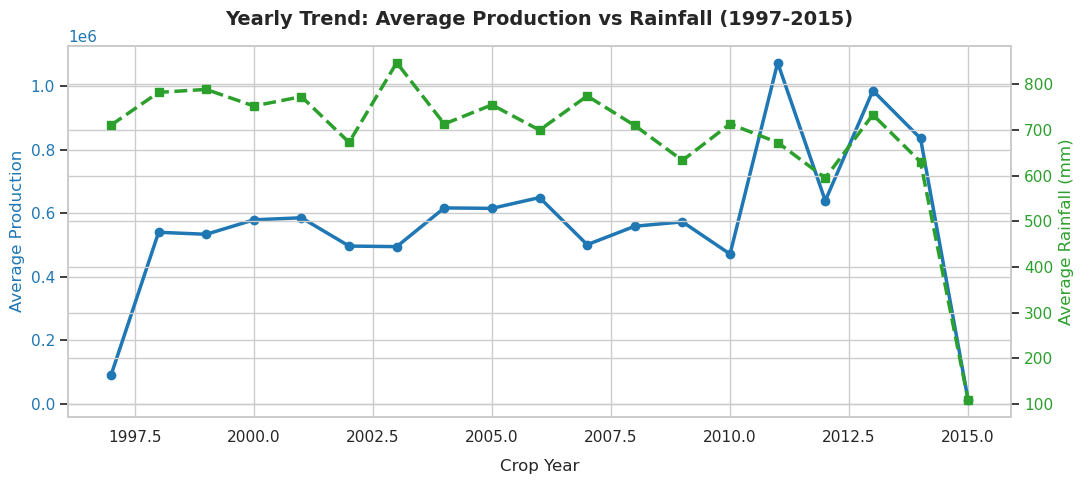

In [13]:
#********************YEAR-WISE PRODUCTION & RAINFALL TREND ANALYSIS(LINE CHART)*******************
# Calculate yearly averages for production and rainfall
yearly_data = df.groupby('Crop_Year')[['Production', 'Rainfall']].mean().reset_index()

# Create figure and primary axis for production
fig, ax1 = plt.subplots(figsize=(11, 5))
sns.set_theme(style="whitegrid")

color = '#1f77b4'
ax1.set_xlabel('Crop Year', fontsize=12, labelpad=10)
ax1.set_ylabel('Average Production', color=color, fontsize=12)
line1 = ax1.plot(yearly_data['Crop_Year'], yearly_data['Production'], color=color, marker='o', linewidth=2.5, label='Avg Production')
ax1.tick_params(axis='y', labelcolor=color)

# Create secondary axis for rainfall
ax2 = ax1.twinx()  
color = '#2ca02c'
ax2.set_ylabel('Average Rainfall (mm)', color=color, fontsize=12)
line2 = ax2.plot(yearly_data['Crop_Year'], yearly_data['Rainfall'], color=color, marker='s', linestyle='--', linewidth=2.5, label='Avg Rainfall')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and format layout
plt.title("Yearly Trend: Average Production vs Rainfall (1997-2015)", fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

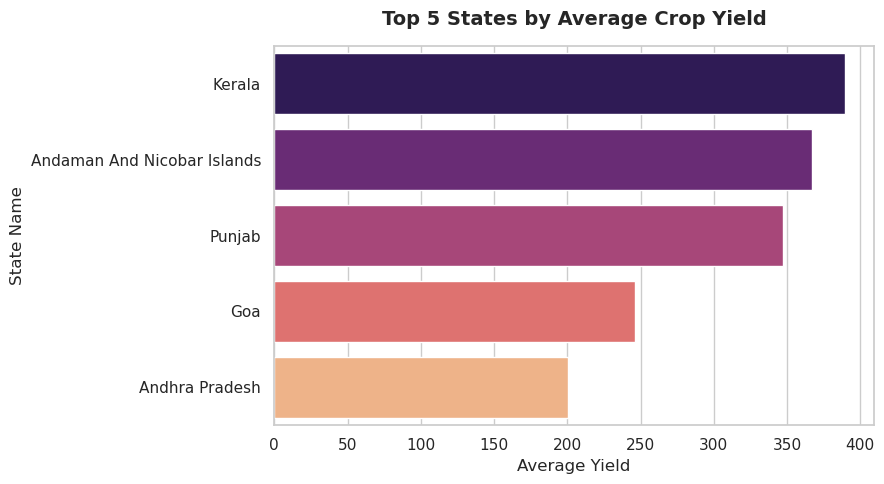

In [14]:
#**************STATE-WISE TOP PERFORMING STATES(SUMMARY TABLE & CHART)*************
# Group by state to find average yield for top 5 states
top_states = df.groupby('State_Name')['Yeild'].mean().nlargest(5).reset_index()

# Set up figure
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# Create bar plot for state yield
sns.barplot(
    data=top_states,
    x='Yeild',
    y='State_Name',
    palette="magma",
    hue='State_Name',
    legend=False
)

# Set titles and labels
plt.title("Top 5 States by Average Crop Yield", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Average Yield", fontsize=12)
plt.ylabel("State Name", fontsize=12)

plt.tight_layout()
plt.show()

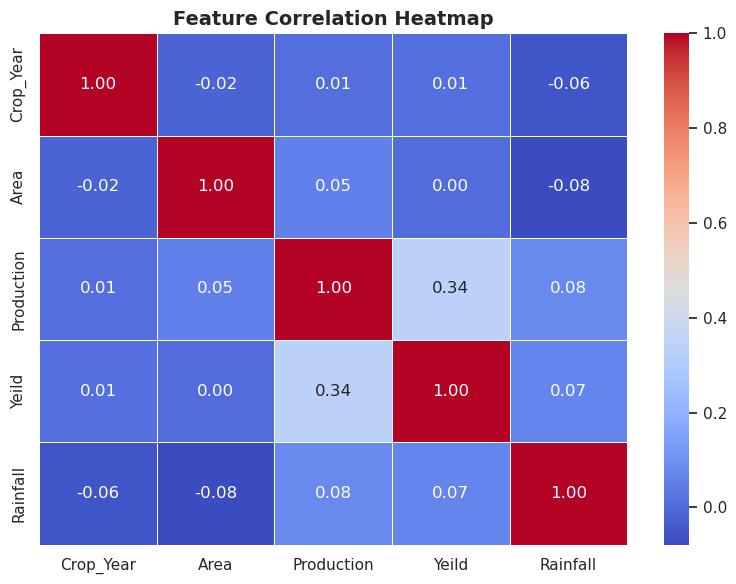

   FEATURE CORRELATION & EXPLORATION COMPLETE     
Data preprocessing and exploratory data analysis finalized successfully.


In [16]:
# Create reports directory to save high-resolution figures for report submission
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Create reports folder if it does not exist
os.makedirs('reports', exist_ok=True)

# 1. Feature Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()

# Save heatmap in high resolution for project report submission
plt.savefig('reports/correlation_heatmap.png', dpi=150)
plt.show()

# 2. Dataset Summary Statistics Log
print("==================================================")
print("   FEATURE CORRELATION & EXPLORATION COMPLETE     ")
print("==================================================")
print("Data preprocessing and exploratory data analysis finalized successfully.")